In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom_test

### data

In [2]:
def meme_count(meme_file):

    count = 0
    with open(meme_file, "r") as f:
        for i in f:
            if i.startswith("MOTIF"):
                count += 1
    return count

In [3]:
def _get_inference_motif_order(motif_file):
    """
    seq2ind:
    for each motif sequence,
    return the order of that sequence in the inferred motif file (single pwm with multiple motifs)

    Parameters
    ----------------
    motif_file: str

    Returns
    ----------------
    dict
    """

    with open(motif_file, "r") as f:
        lines = f.readlines()
    
    ind = 0
    seq2ind = {}
    for line in lines:
        if line.startswith("MOTIF"):
            seq = line.split(" ")[1]
            seq2ind[seq] = ind
            ind += 1
    return seq2ind

In [4]:
def sig_test(array1, array2):
    x = np.sum((array1 - array2) > 0)
    n = np.sum((array1 - array2) != 0)
    pval = binom_test(x, n, alternative='two-sided')

    if (array1.mean() - array2.mean()) > 0:
        pval = pval/2
    else:
        pval = 1
    return pval

In [5]:
fb = [i.replace(".tomtom", "") for i in os.listdir("/home/jg2447/slayman/motif_inference/result/compareMotifDB/factorbook/inference_tomtom") if not i.startswith(".") and i.endswith(".tomtom")]
manolis = [i.replace(".tomtom", "") for i in os.listdir("/home/jg2447/slayman/motif_inference/result/compareMotifDB/manolis/inference_tomtom") if not i.startswith(".") and i.endswith(".tomtom")]
known = [i.replace(".tomtom", "") for i in os.listdir("/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_tomtom") if not i.startswith(".") and i.endswith(".tomtom")]

In [6]:
fb_vs_known = set.intersection(set(fb), set(known))
manolis_vs_known = set.intersection(set(manolis), set(known))

In [7]:
fb_hits = []
known_hits = []
best_hits = []
for i in fb_vs_known:
    fb_meme_file = "/home/jg2447/slayman/data/motif_factorbook/meme_human_stack/%s.meme" % i
    fb_count = meme_count(fb_meme_file)
    known_meme_file = "/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_motif/%s.meme" % i
    known_count = meme_count(known_meme_file)
    count = min(known_count, fb_count, 5)
      
    df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/compareMotifDB/factorbook/inference_tomtom/%s.tomtom" % i, sep="\t")
    df = df[df['p-value'] <= 0.05]
    df = df.sort_values('p-value').drop_duplicates("#Query ID")
    df = df[df["#Query ID"].str.split("_").str[1].astype(int) < count].copy()
    fb_hits.append(df.shape[0])
    
    df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_tomtom/%s.tomtom" % i, sep="\t")
    df = df[df['p-value'] <= 0.05]
    df = df.sort_values('p-value').drop_duplicates("#Query ID")
    motif_file = "/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_motif/%s.meme" % i
    seq2ind = _get_inference_motif_order(motif_file)
    df = df[df["#Query ID"].map(seq2ind) < count].copy()
    known_hits.append(df.shape[0])
    
    df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/compareMotifDB/mobi/inference_tomtom/%s.tomtom" % i, sep="\t")
    df = df[df['p-value'] <= 0.05]
    df = df.sort_values('p-value').drop_duplicates("#Query ID")
    motif_file = "/home/jg2447/slayman/motif_inference/result/compareMotifDB/mobi/inference_motif/%s.meme" % i
    seq2ind = _get_inference_motif_order(motif_file)
    df = df[df["#Query ID"].map(seq2ind) < count].copy()
    best_hits.append(df.shape[0])

In [8]:
df1 = pd.DataFrame([fb_hits, known_hits, best_hits, fb_vs_known]).transpose()

In [9]:
sig_test(np.array(known_hits), np.array(fb_hits))

0.0045366701697935885

In [10]:
df1.mean()

0    1.178082
1    1.849315
2    2.630137
dtype: float64

In [11]:
manolis_hits = []
known_hits = []
best_hits = []
for i in manolis_vs_known:
    manolis_meme_file = "/home/jg2447/slayman/data/motif_manolis/meme_human_stack/%s.meme" % i
    manolis_count = meme_count(manolis_meme_file)
    known_meme_file = "/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_motif/%s.meme" % i
    known_count = meme_count(known_meme_file)
    count = min(known_count, manolis_count, 5)
      
    df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/compareMotifDB/manolis/inference_tomtom/%s.tomtom" % i, sep="\t")
    df = df[df['p-value'] <= 0.05]
    df = df.sort_values('p-value').drop_duplicates("#Query ID")
    df = df[df["#Query ID"].str.split("_").str[1].astype(int) < count].copy()
    manolis_hits.append(df.shape[0])
    
    df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_tomtom/%s.tomtom" % i, sep="\t")
    df = df[df['p-value'] <= 0.05]
    df = df.sort_values('p-value').drop_duplicates("#Query ID")
    motif_file = "/home/jg2447/slayman/motif_inference/result/compareMotifDB/baseline/inference_motif/%s.meme" % i
    seq2ind = _get_inference_motif_order(motif_file)
    df = df[df["#Query ID"].map(seq2ind) < count].copy()
    known_hits.append(df.shape[0])
    
    df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/compareMotifDB/mobi/inference_tomtom/%s.tomtom" % i, sep="\t")
    df = df[df['p-value'] <= 0.05]
    df = df.sort_values('p-value').drop_duplicates("#Query ID")
    motif_file = "/home/jg2447/slayman/motif_inference/result/compareMotifDB/mobi/inference_motif/%s.meme" % i
    seq2ind = _get_inference_motif_order(motif_file)
    df = df[df["#Query ID"].map(seq2ind) < count].copy()
    best_hits.append(df.shape[0])

In [12]:
df2 = pd.DataFrame([manolis_hits, known_hits, best_hits, manolis_vs_known]).transpose()

In [13]:
sig_test(np.array(manolis_hits), np.array(known_hits))

0.49999999999999994

In [14]:
df2.mean()

0    1.600000
1    1.433333
2    1.933333
dtype: float64

### plot

In [15]:
color1 = (0.3,0.9,0.4,0.6)
color2 = (0.3,0.5,0.4,0.6)
color3 = (0.3,0.1,0.4,0.6)

In [16]:
def plt_ax_trim(ax_i):
    """
    From sns.utils -> despine function -> trim parameter
    See https://github.com/mwaskom/seaborn/blob/master/seaborn/utils.py
    """
    xticks = ax_i.get_xticks()
    if xticks.size:
        firsttick = np.compress(xticks >= min(ax_i.get_xlim()),
                                xticks)[0]
        lasttick = np.compress(xticks <= max(ax_i.get_xlim()),
                               xticks)[-1]
        ax_i.spines['bottom'].set_bounds(firsttick, lasttick)
        ax_i.spines['top'].set_bounds(firsttick, lasttick)
        newticks = xticks.compress(xticks <= lasttick)
        newticks = newticks.compress(newticks >= firsttick)
        ax_i.set_xticks(newticks)

    yticks = ax_i.get_yticks()
    if yticks.size:
        firsttick = np.compress(yticks >= min(ax_i.get_ylim()),
                                yticks)[0]
        lasttick = np.compress(yticks <= max(ax_i.get_ylim()),
                               yticks)[-1]
        ax_i.spines['left'].set_bounds(firsttick, lasttick)
        ax_i.spines['right'].set_bounds(firsttick, lasttick)
        newticks = yticks.compress(yticks <= lasttick)
        newticks = newticks.compress(newticks >= firsttick)
        ax_i.set_yticks(newticks)

In [17]:
## Author: cheersmate
## https://stackoverflow.com/questions/11517986/indicating-the-statistically-significant-difference-in-bar-graph

def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=3):
    """ 
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = ax.get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh+0.03)

    ax.plot(barx, bary, c='black', lw=0.5)

    kwargs = dict(ha='center', va='bottom')
    kwargs['fontsize'] = 5
    ax.text(*mid, text, **kwargs)

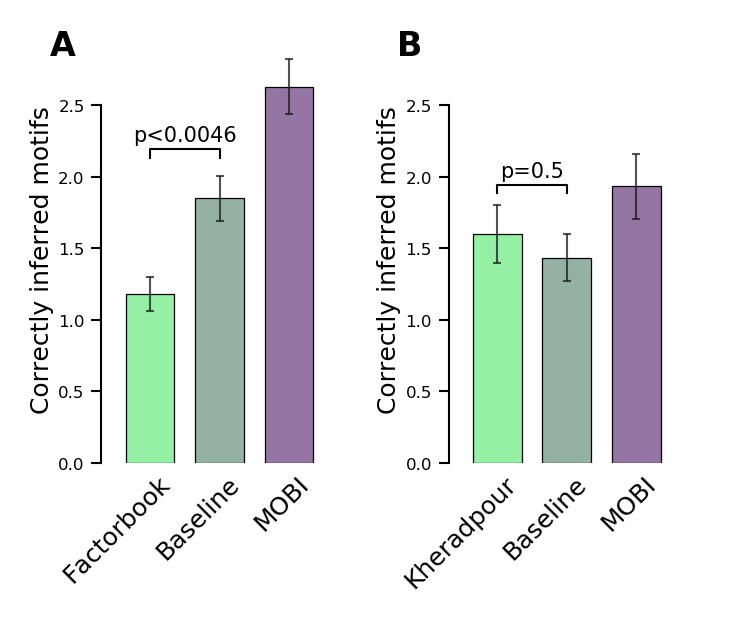

In [18]:
sns.set_context("paper")

fig, axs = plt.subplots(1, 2, figsize=(2.6,1.8), dpi=300, gridspec_kw={'wspace': 0.35})
ax = axs[0]

ax.bar(
    [0,1,2],
    df1.mean().values,
    width=0.7,
    bottom=[0,0,0],
    color=[color1, color2, color3],
    linewidth=0.3,
    edgecolor="black")

_, caps, sticks = ax.errorbar(
    x=[0,1,2],
    y=df1.mean().values,
    yerr=df1.sem().values,
    fmt=".",
    lw=1,
    capsize=1,
    markersize=0,
    elinewidth=0.5,
    ecolor=(0.1, 0.1, 0.1, 0.75))
for cap in caps:
     cap.set_markeredgewidth(0.5)

ax.set_ylim([0,2.85])
ax.set_xlim([-0.7,3])

ax.get_xaxis().set_ticks([0.35,1.35,2.35])
ax.get_xaxis().set_ticklabels(["Factorbook", "Baseline", "MOBI"], rotation=45, ha="right")
ax.get_xaxis().set_tick_params(size=0, pad=2, labelsize=6)

ax.get_yaxis().set_ticks([0,0.5,1.0,1.5,2.0,2.5])
ax.get_yaxis().set_tick_params(size=2.5, width=0.5, pad=1.5, labelsize=4)
ax.set_ylabel("Correctly inferred motifs", fontsize=6, labelpad=1)

#ax.legend([ax.patches[0], ax.patches[1], ax.patches[2]], ["DREME", "HOMER", "MEME"], fontsize=5, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt_ax_trim(ax)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.text(-0.2, 1, "A", transform=ax.transAxes, size=8, weight='bold')
barplot_annotate_brackets(0,1,"p<0.0046", [0,1,2], df1.mean().values+0.2, barh=0.02, dh=0.03)

####
ax = axs[1]

ax.bar(
    [0,1,2],
    df2.mean().values,
    width=0.7,
    bottom=[0,0,0],
    color=[color1, color2, color3],
    linewidth=0.3,
    edgecolor="black")

_, caps, sticks = ax.errorbar(
    x=[0,1,2],
    y=df2.mean().values,
    yerr=df2.sem().values,
    fmt=".",
    lw=1,
    capsize=1,
    markersize=0,
    elinewidth=0.5,
    ecolor=(0.1, 0.1, 0.1, 0.75))
for cap in caps:
     cap.set_markeredgewidth(0.5)

ax.set_ylim([0,2.85])
ax.set_xlim([-0.7,3])

ax.get_xaxis().set_ticks([0.35,1.35,2.35])
ax.get_xaxis().set_ticklabels(["Kheradpour", "Baseline", "MOBI"], rotation=45, ha="right")
ax.get_xaxis().set_tick_params(size=0, pad=2, labelsize=6)

ax.get_yaxis().set_ticks([0,0.5,1.0,1.5,2.0,2.5])
ax.get_yaxis().set_tick_params(size=2.5, width=0.5, pad=1.5, labelsize=4)
ax.set_ylabel("Correctly inferred motifs", fontsize=6, labelpad=1)

plt_ax_trim(ax)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.text(-0.2, 1, "B", transform=ax.transAxes, size=8, weight='bold')
barplot_annotate_brackets(0,1,"p=0.5", [0,1,2], df2.mean().values+0.2, barh=0.02, dh=0.03)

plt.savefig("./fig7.pdf", dpi="figure", bbox_inches="tight")